<a href="https://colab.research.google.com/github/HimanshuRa0/Deep-learning/blob/main/EXP_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 17: Autoencoders for Dimensionality Reduction

**Objective:** To implement an autoencoder for dimensionality reduction using Python.

**Tools/Libraries:** Python, NumPy, Pandas, Matplotlib, scikit-learn, TensorFlow/Keras

**Estimated Time:** 2 hours


## 1. Introduction

An **autoencoder** is a neural network that learns to compress input data into a lower-dimensional representation and then reconstruct it back. It has two main parts:

- **Encoder:** compresses the data
- **Decoder:** reconstructs the original data

For dimensionality reduction, we use the compressed representation (also called **latent space** or **bottleneck features**).


## 2. Aim of the Experiment

In this notebook, we will:

1. Load a standard dataset
2. Preprocess and scale the features
3. Build an autoencoder model
4. Train the model
5. Extract low-dimensional representations
6. Visualize the reduced features
7. Compare reconstruction quality


In [1]:
# Install TensorFlow if needed
# !pip install tensorflow scikit-learn matplotlib pandas numpy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

np.random.seed(42)

## 3. Load Dataset

We will use the **Digits dataset** from scikit-learn. It contains 8x8 grayscale images of handwritten digits.


In [3]:
digits = load_digits()
X = digits.data
y = digits.target

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (1797, 64)
Target shape: (1797,)


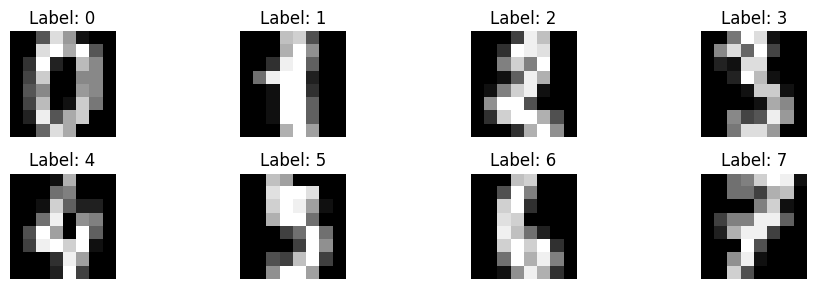

In [4]:
# Display a few sample images
plt.figure(figsize=(10, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X[i].reshape(8, 8), cmap='gray')
    plt.title(f'Label: {y[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

We scale the pixel values between 0 and 1 so that the neural network trains more effectively.


In [5]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)

Training data shape: (1437, 64)
Testing data shape: (360, 64)


## 5. Build the Autoencoder

We create a simple dense autoencoder with:

- Input layer of 64 neurons
- Hidden encoder layers
- Bottleneck layer of 2 neurons for dimensionality reduction
- Decoder to reconstruct the original 64-dimensional input


In [6]:
input_dim = X_train.shape[1]   # 64
encoding_dim = 2               # reduced dimension

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(16, activation='relu')(encoded)
bottleneck = Dense(encoding_dim, activation='linear', name='bottleneck')(encoded)

# Decoder
decoded = Dense(16, activation='relu')(bottleneck)
decoded = Dense(32, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='sigmoid')(decoded)

# Full autoencoder model
autoencoder = Model(inputs=input_layer, outputs=output_layer)

# Encoder model for dimensionality reduction
encoder = Model(inputs=input_layer, outputs=bottleneck)

autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,346 (20.88 KB)

 Trainable params: 5,346 (20.88 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model


In [7]:
history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_test, X_test),
    epochs=50,
    batch_size=32,
    shuffle=True,
    verbose=1
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.1525 - val_loss: 0.0989
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0802 - val_loss: 0.0759
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0732 - val_loss: 0.0720
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0683 - val_loss: 0.0667
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0646 - val_loss: 0.0643
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0627 - val_loss: 0.0626
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0613 - val_loss: 0.0613
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0599 - val_loss: 0.0602
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0590 - val_loss: 0.0591
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0582 - val_loss: 0.0586
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0574 - val_loss: 0.0579
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0566 - v

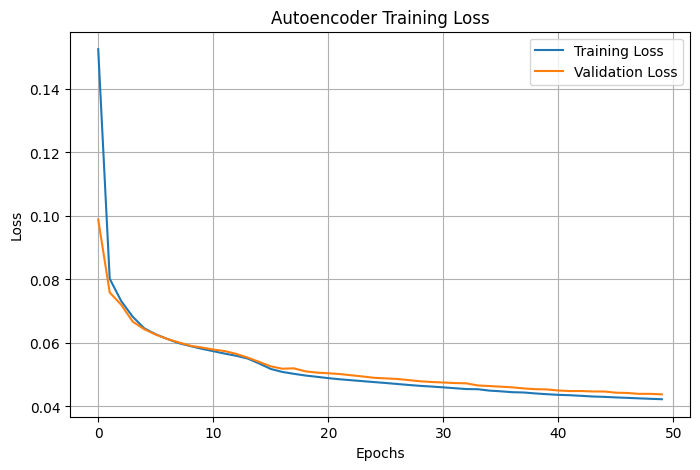

In [8]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.grid(True)
plt.show()

## 7. Dimensionality Reduction

Now we use the trained encoder to convert 64-dimensional input data into 2-dimensional latent vectors.


In [9]:
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

print('Encoded training shape:', X_train_encoded.shape)
print('Encoded testing shape:', X_test_encoded.shape)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Encoded training shape: (1437, 2)
Encoded testing shape: (360, 2)


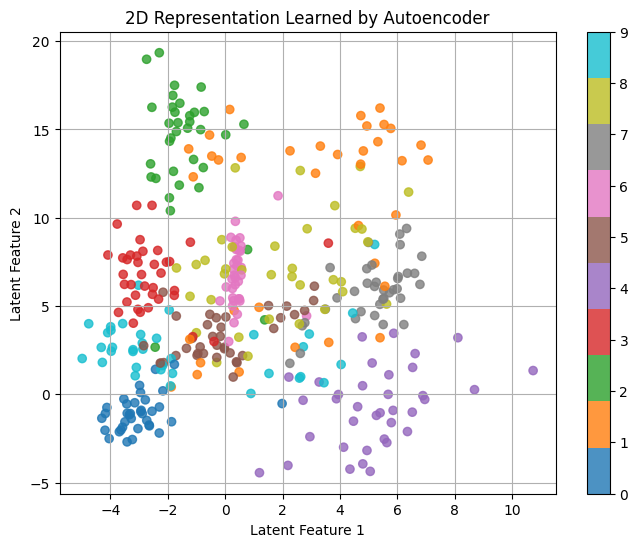

In [10]:
# Visualize the 2D latent space
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_test_encoded[:, 0], X_test_encoded[:, 1], c=y_test, cmap='tab10', alpha=0.8)
plt.xlabel('Latent Feature 1')
plt.ylabel('Latent Feature 2')
plt.title('2D Representation Learned by Autoencoder')
plt.colorbar(scatter)
plt.grid(True)
plt.show()

## 8. Compare with PCA

For understanding, we compare the autoencoder-based reduction with PCA.


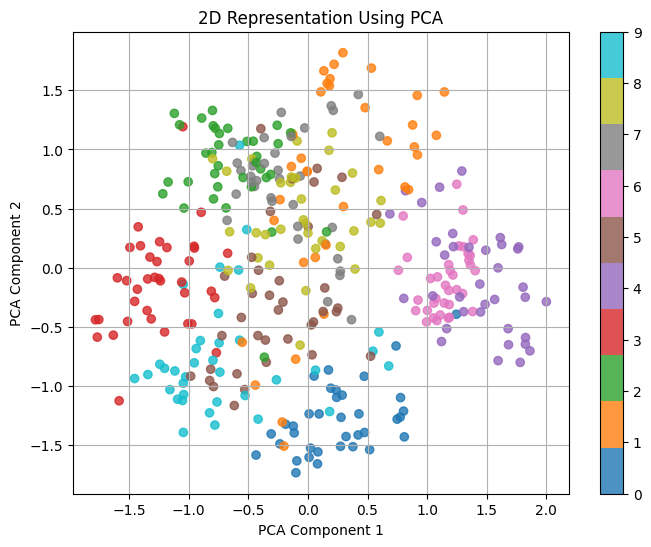

In [11]:
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='tab10', alpha=0.8)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('2D Representation Using PCA')
plt.colorbar(scatter)
plt.grid(True)
plt.show()

## 9. Reconstruction Check

We now reconstruct the test images using the autoencoder and compare original vs reconstructed samples.


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


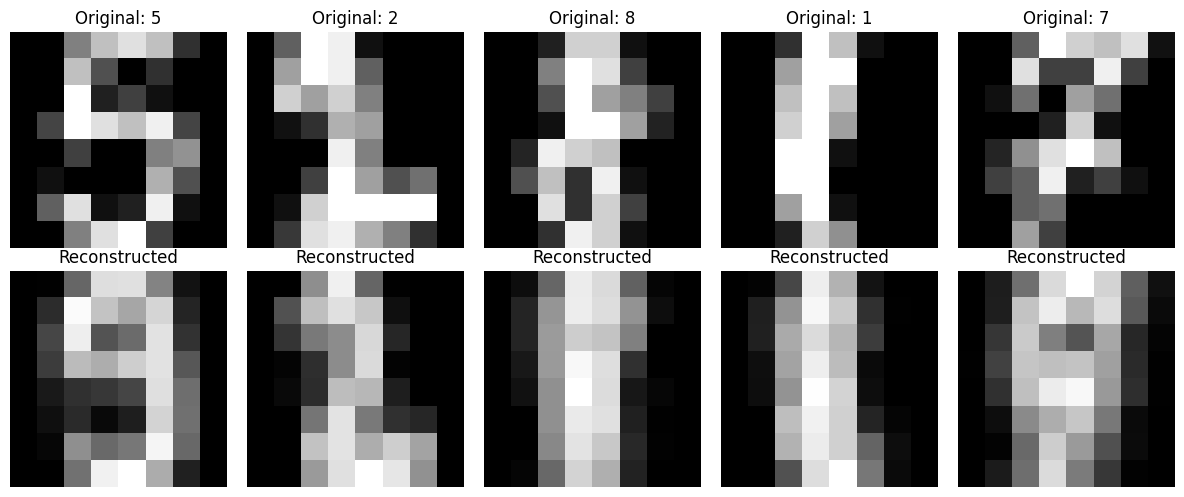

In [12]:
X_reconstructed = autoencoder.predict(X_test)

n = 5
plt.figure(figsize=(12, 5))
for i in range(n):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
    plt.title(f'Original: {y_test[i]}')
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(X_reconstructed[i].reshape(8, 8), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')

plt.tight_layout()
plt.show()

## 10. Conclusion

In this experiment, we implemented an autoencoder for dimensionality reduction. The model learned a compressed 2-dimensional representation of image data and successfully reconstructed the original input with reasonable accuracy. This shows that autoencoders are useful for learning compact nonlinear feature representations.
